# Audit preprocessing Suh dan penyelarasan eksperimen

**Hasil audit:** 8.681 rekaman benchmark, 200 nama label, 100 label ringkasan acuan.
Notebook memeriksa data, fitur, dan pembagian; **tidak melatih model atau menilai prediksi test**.

Sumber: [Suh et al.](https://doi.org/10.1038/s42004-025-01651-7), [OSF](https://osf.io/vfru6/), CC BY 4.0.
Kode asli hanya dibaca. Kesalahan reset indeks diperbaiki sebelum membentuk fitur dan target.
Dataset lima sumber/25 label dan notebook sebelumnya adalah riwayat terpisah.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "alignment/data.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from alignment.data import REFERENCE, OUTPUT, COLS, verify_reference, curate, encode, features, partition
manifest = json.loads((OUTPUT / "dataset_manifest.json").read_text(encoding="utf-8"))
print("Referensi cocok SHA-256:", len(verify_reference()))
print("RDKit:", manifest["feature_spec"]["rdkit_version"])

Referensi cocok SHA-256: 3
RDKit: 2026.03.4


## 1. Data dan nilai kosong

Satu baris adalah rekaman struktur dan maksimal tiga slot istilah IFRA.
Slot kosong bukan aroma negatif yang sudah diuji. Baris tanpa SMILES/MolBlock dikeluarkan mengikuti urutan acuan.

In [2]:
raw = pd.read_csv(REFERENCE / "Dataset2_final_w_molblock.csv")
display(pd.DataFrame({"nilai_kosong": raw[["smiles", "molblock", *COLS]].isna().sum()}))
display(raw.drop(columns="molblock").head(5))

,nilai_kosong
smiles,0
molblock,46
ifra1,0
ifra2,1826
ifra3,2687


,smiles,cid,ifra1,ifra2,ifra3
0,CC(CN)O,4,Fishy,Chemical,Unpleasant
1,C1=CC(=C(C(=C1)O)O)C(=O)O,19,Odorless,NaN,NaN
2,CC(C)C(=O)C(=O)O,49,Fruity,Lemon,Sweet
3,C(CC(=O)O)C(=O)C(=O)O,51,Odorless,NaN,NaN
4,CCC(=O)C(=O)O,58,Caramel,Creamy,Sweet


## 2. Penyaringan dengan identitas baris tetap

Notebook penulis membentuk fitur lebih dahulu, menyaring strata dengan satu anggota, lalu mengatur ulang indeks hanya pada tabel rekaman. Indeks baru dipakai mengambil fitur lama. Sampel pembagian tidak sesuai dengan tabel yang dimaksud; fitur dan target lama sendiri masih berpasangan.

Perbaikan: simpan source_row, saring tabel dahulu, lalu bentuk seluruh matriks dari tabel yang sama. Tidak ada pemilihan berdasarkan skor model.

In [3]:
frame, labels, summary_labels, audit = curate(raw)
display(pd.DataFrame([{"tahap": k, "jumlah": audit[k]} for k in [
    "raw_rows", "unique_smiles_rows", "after_required_values", "benchmark_rows",
    "label_registry_count", "paper_summary_label_count", "index_mapping_different_positions"]]))
assert audit["benchmark_rows"] == 8681
assert labels == manifest["labels"]
assert summary_labels == manifest["summary_labels"]

,tahap,jumlah
0,raw_rows,8806
1,unique_smiles_rows,8746
2,after_required_values,8700
3,benchmark_rows,8681
4,label_registry_count,200
5,paper_summary_label_count,100
6,index_mapping_different_positions,7075


## 3. Encoding label dan subset ringkasan

Matriks target memiliki 200 kolom. Label yang muncul dua kali pada slot satu rekaman tetap menghasilkan satu nilai positif.

Ringkasan artikel menggunakan 100 istilah dengan sedikitnya 30 **kemunculan slot** sebelum penyaringan strata. Daftar dibekukan sebagai kelompok pembanding eksternal; bukan dipilih dari skor test atau dianggap seluruh label yang dilatih.

In [4]:
Y = encode(frame, labels)
print("Bentuk target:", Y.shape)
print("Label ringkasan:", len(summary_labels))
display(pd.DataFrame({"label": labels}).head(10))

Bentuk target: (8681, 200)
Label ringkasan: 100


,label
0,ACIDIC
1,ALCOHOLIC
2,ALDEHYDIC
3,ALLIACEOUS
4,ALMOND
5,AMBER
6,ANIMAL
7,ANISIC
8,APPLE
9,APRICOT


## 4. Morgan dan lima deskriptor

Morgan mengikuti kode acuan: radius 2, 1.024 bit, tanpa kiralitas, dari MolBlock. Lima deskriptor dihitung dari SMILES. A/C memakai 1.024 fitur; B/D memakai 1.029.

Struktur yang gagal dibaca menghentikan proses, bukan diam-diam diberi nol. Benchmark mempertahankan 557 struktur multifragmen; API tetap hanya mendukung satu molekul terhubung. Satu rekaman isotop berbeda fingerprint SMILES–MolBlock dan dicatat sebagai batas kesesuaian inferensi.

In [5]:
X, descriptors, structure_audit = features(frame)
print("Morgan:", X.shape, "deskriptor:", descriptors.shape)
display(pd.DataFrame({"deskriptor": manifest["feature_spec"]["descriptors"],
                      "minimum": descriptors.min(axis=0), "maksimum": descriptors.max(axis=0)}))
print("Multifragmen:", structure_audit["multifragment_records"])
print("Baris beda Morgan SMILES/MolBlock:", structure_audit["morgan_smiles_molblock_mismatch_source_rows"])

Morgan: (8681, 1024) deskriptor: (8681, 5)
Multifragmen: 557
Baris beda Morgan SMILES/MolBlock: [4523]


,deskriptor,minimum,maksimum
0,MolWt,3.022102,2632.993896
1,MolLogP,-43.247799,47.055000
2,NumHDonors,0.000000,24.000000
3,NumHAcceptors,0.000000,50.000000
4,TPSA,0.000000,748.760010


## 5. Split dan fold

Seed 42 dan test 20% mengikuti acuan. Stratifikasi luar memakai istilah pertama menurut alfabet. CV dibuat per label dengan minimum dari 5, jumlah positif training, dan jumlah negatif training. Label dengan kurang dari dua contoh pada salah satu kelas tidak dilatih.

Seluruh kondisi A–D memakai pembagian sama. Array test tersimpan terpisah dan tidak dibuka oleh notebook.

In [6]:
split = partition(frame, Y, labels)
saved_split = json.loads((OUTPUT / "splits.json").read_text(encoding="utf-8"))
assert split["train"] == saved_split["train"]
assert split["test"] == saved_split["test"]
assert split["folds"] == saved_split["folds"]
assert not set(split["train"]) & set(split["test"])
with np.load(OUTPUT / "train.npz", allow_pickle=False) as saved:
    rows = split["train"]
    assert np.array_equal(X[rows], saved["morgan"])
    assert np.array_equal(descriptors[rows], saved["descriptors"])
    assert np.array_equal(Y[rows], saved["truth"])
    assert np.array_equal(frame.source_row.to_numpy()[rows], saved["source_row"])
support = pd.DataFrame(split["support"])
print("Training:", len(split["train"]), "Test:", len(split["test"]))
print("Label dapat dilatih:", int(support.eligible.sum()))
print("Seluruh 100 label ringkasan dapat dilatih:", set(summary_labels).issubset(split["eligible_labels"]))
display(support.groupby("folds").size().rename("jumlah_label").to_frame())

Training: 6944 Test: 1737
Label dapat dilatih: 186
Seluruh 100 label ringkasan dapat dilatih: True


,jumlah_label
folds,
0,14
2,8
3,14
4,12
5,152


## 6. Distribusi label training

Gambar pertama menampilkan 20 label training terbanyak; ini visualisasi ringkas, bukan pembatasan target. Gambar kedua menunjukkan jumlah fold yang tersedia untuk seluruh 200 label.

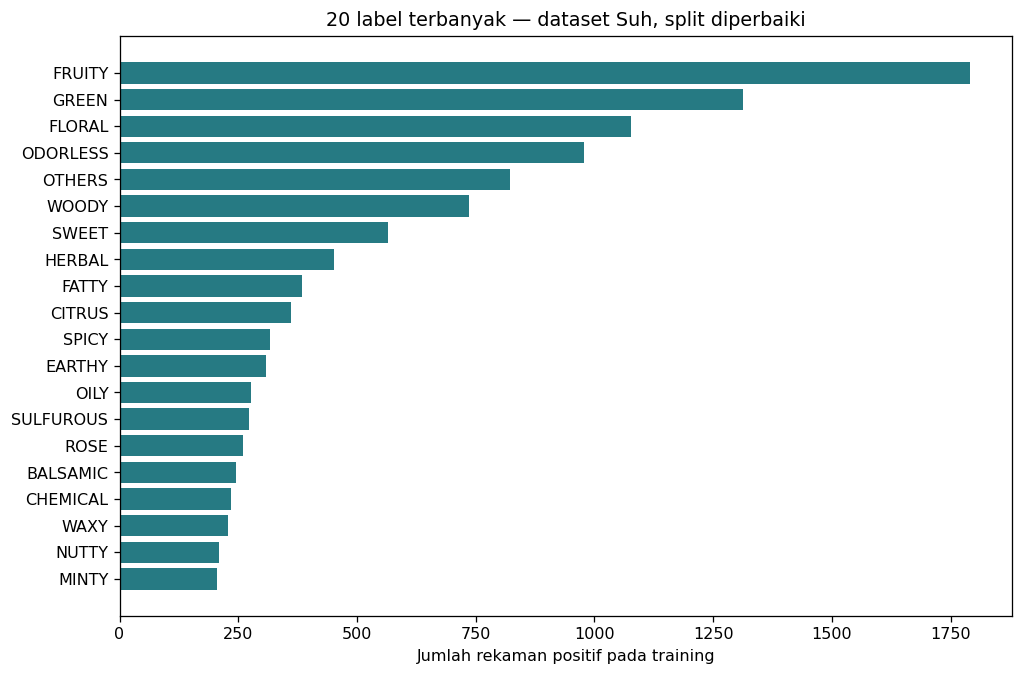

In [7]:
top = support.sort_values("train_positive").tail(20)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top.label, top.train_positive, color="#267a83")
ax.set_xlabel("Jumlah rekaman positif pada training")
ax.set_title("20 label terbanyak — dataset Suh, split diperbaiki")
fig.tight_layout()
display(fig)
fig.savefig(ROOT / "reports/alignment_20260910/training_label_distribution.png", dpi=160)
plt.close(fig)

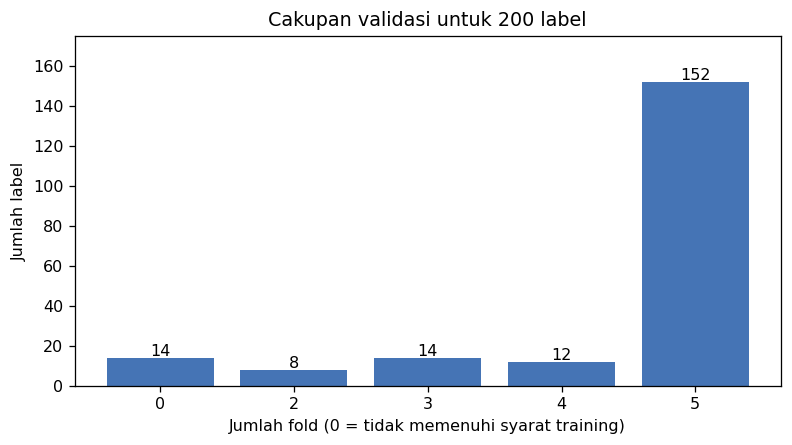

In [8]:
counts = support.groupby("folds").size()
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([str(x) for x in counts.index], counts.values, color="#4574b5")
ax.set_xlabel("Jumlah fold (0 = tidak memenuhi syarat training)")
ax.set_ylabel("Jumlah label")
ax.set_title("Cakupan validasi untuk 200 label")
for i, n in enumerate(counts.values):
    ax.text(i, n + 1, str(n), ha="center")
ax.set_ylim(0, counts.max() * 1.15)
fig.tight_layout()
display(fig)
fig.savefig(ROOT / "reports/alignment_20260910/fold_coverage.png", dpi=160)
plt.close(fig)

## Kesimpulan dan batas penggunaan

- Data, target, fitur, dan split ditelusuri ke file penulis yang hash-nya terverifikasi.
- Daftar berisi 200 label; 186 memenuhi syarat training. Ringkasan utama memakai 100 label tetap.
- Koreksi indeks mengubah keanggotaan pembagian. Pembanding utama wajib baseline yang dilatih ulang dengan koreksi sama.
- AUPRC acuan adalah Average Precision; accuracy adalah accuracy biner per label.
- Tidak ada hasil model atau bukti peningkatan performa dari notebook ini.
- Multifragmen dan perbedaan struktur isotop membatasi klaim aplikasi. Validasi ekspor dan API menunggu model tersedia.